# Machine Learning - Regression

In [111]:
# Install Pandas and Numpy library
%pip install pandas
%pip install numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [112]:
import pandas as pd
import numpy as np

## 1. Data Preparation

In [113]:
url = "D:/Class Study/Data Science/Machine Learning - T2/Homework/Homework 2/student+performance/student/student-mat.csv"
df = pd.read_csv(url, delimiter=";")

df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [114]:
df.loc[100]

school              GP
sex                  M
age                 16
address              U
famsize            GT3
Pstatus              T
Medu                 4
Fedu                 4
Mjob          services
Fjob          services
reason           other
guardian        mother
traveltime           1
studytime            1
failures             0
schoolsup          yes
famsup             yes
paid               yes
activities         yes
nursery            yes
higher             yes
internet           yes
romantic            no
famrel               4
freetime             5
goout                5
Dalc                 5
Walc                 5
health               4
absences            14
G1                   7
G2                   7
G3                   5
Name: 100, dtype: object

In [115]:
df.columns = df.columns.str.lower()
df.columns

Index(['school', 'sex', 'age', 'address', 'famsize', 'pstatus', 'medu', 'fedu',
       'mjob', 'fjob', 'reason', 'guardian', 'traveltime', 'studytime',
       'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery',
       'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'dalc',
       'walc', 'health', 'absences', 'g1', 'g2', 'g3'],
      dtype='object')

In [116]:
df.dtypes == 'Object'

school        False
sex           False
age           False
address       False
famsize       False
pstatus       False
medu          False
fedu          False
mjob          False
fjob          False
reason        False
guardian      False
traveltime    False
studytime     False
failures      False
schoolsup     False
famsup        False
paid          False
activities    False
nursery       False
higher        False
internet      False
romantic      False
famrel        False
freetime      False
goout         False
dalc          False
walc          False
health        False
absences      False
g1            False
g2            False
g3            False
dtype: bool

In [117]:
strings = list(df.dtypes.index)
strings

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'pstatus',
 'medu',
 'fedu',
 'mjob',
 'fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'dalc',
 'walc',
 'health',
 'absences',
 'g1',
 'g2',
 'g3']

In [118]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   pstatus     395 non-null    object
 6   medu        395 non-null    int64 
 7   fedu        395 non-null    int64 
 8   mjob        395 non-null    object
 9   fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [119]:
df.describe()

,age,medu,fedu,traveltime,studytime,failures,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,16.696203,2.749367,2.521519,1.448101,2.035443,0.334177,3.944304,3.235443,3.108861,1.481013,2.291139,3.554430,5.708861,10.908861,10.713924,10.415190
std,1.276043,1.094735,1.088201,0.697505,0.839240,0.743651,0.896659,0.998862,1.113278,0.890741,1.287897,1.390303,8.003096,3.319195,3.761505,4.581443
min,15.000000,0.000000,0.000000,1.000000,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,16.000000,2.000000,2.000000,1.000000,1.000000,0.000000,4.000000,3.000000,2.000000,1.000000,1.000000,3.000000,0.000000,8.000000,9.000000,8.000000
50%,17.000000,3.000000,2.000000,1.000000,2.000000,0.000000,4.000000,3.000000,3.000000,1.000000,2.000000,4.000000,4.000000,11.000000,11.000000,11.000000
75%,18.000000,4.000000,3.000000,2.000000,2.000000,0.000000,5.000000,4.000000,4.000000,2.000000,3.000000,5.000000,8.000000,13.000000,13.000000,14.000000
max,22.000000,4.000000,4.000000,4.000000,4.000000,3.000000,5.000000,5.000000,5.000000,5.000000,5.000000,5.000000,75.000000,19.000000,19.000000,20.000000


## 2. EDA - Exploration Data Analysis

In [120]:
strings

['school',
 'sex',
 'age',
 'address',
 'famsize',
 'pstatus',
 'medu',
 'fedu',
 'mjob',
 'fjob',
 'reason',
 'guardian',
 'traveltime',
 'studytime',
 'failures',
 'schoolsup',
 'famsup',
 'paid',
 'activities',
 'nursery',
 'higher',
 'internet',
 'romantic',
 'famrel',
 'freetime',
 'goout',
 'dalc',
 'walc',
 'health',
 'absences',
 'g1',
 'g2',
 'g3']

In [121]:
for col in strings:
    df[col]

In [122]:
for col in df.columns:
    print(col)
    print(df[col].unique()[:10])
    print(df[col].nunique())

school
['GP' 'MS']
2
sex
['F' 'M']
2
age
[18 17 15 16 19 22 20 21]
8
address
['U' 'R']
2
famsize
['GT3' 'LE3']
2
pstatus
['A' 'T']
2
medu
[4 1 3 2 0]
5
fedu
[4 1 2 3 0]
5
mjob
['at_home' 'health' 'other' 'services' 'teacher']
5
fjob
['teacher' 'other' 'services' 'health' 'at_home']
5
reason
['course' 'other' 'home' 'reputation']
4
guardian
['mother' 'father' 'other']
3
traveltime
[2 1 3 4]
4
studytime
[2 3 1 4]
4
failures
[0 3 2 1]
4
schoolsup
['yes' 'no']
2
famsup
['no' 'yes']
2
paid
['no' 'yes']
2
activities
['no' 'yes']
2
nursery
['yes' 'no']
2
higher
['yes' 'no']
2
internet
['no' 'yes']
2
romantic
['no' 'yes']
2
famrel
[4 5 3 1 2]
5
freetime
[3 2 4 1 5]
5
goout
[4 3 2 1 5]
5
dalc
[1 2 5 3 4]
5
walc
[1 3 2 4 5]
5
health
[3 5 1 2 4]
5
absences
[ 6  4 10  2  0 16 14  7  8 25]
34
g1
[ 5  7 15  6 12 16 14 10 13  8]
17
g2
[ 6  5  8 14 10 15 12 18 16 13]
17
g3
[ 6 10 15 11 19  9 12 14 16  5]
18


In [123]:
%pip install seaborn matplotlib

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [124]:
import seaborn as sns
import matplotlib.pyplot as plt

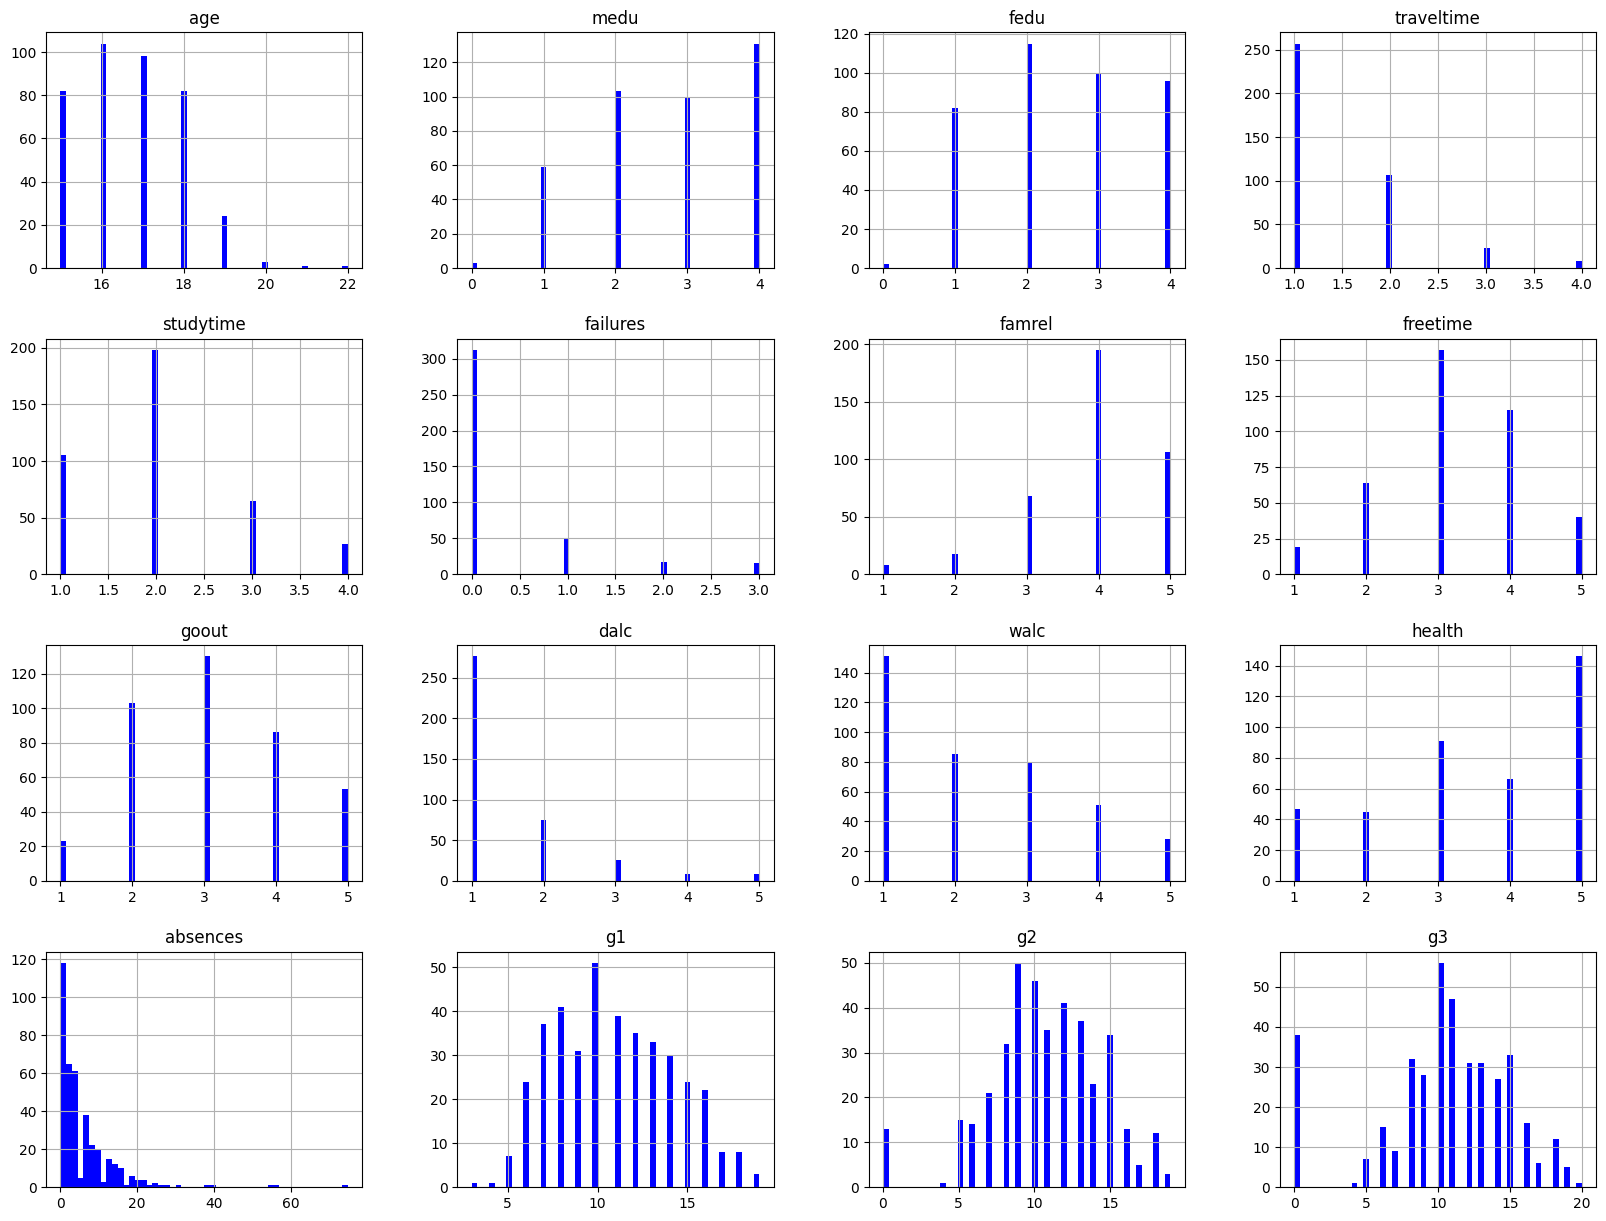

In [125]:
df.hist(bins=50, figsize=(20,15), color='b')
plt.show()

<Axes: xlabel='g3', ylabel='Count'>

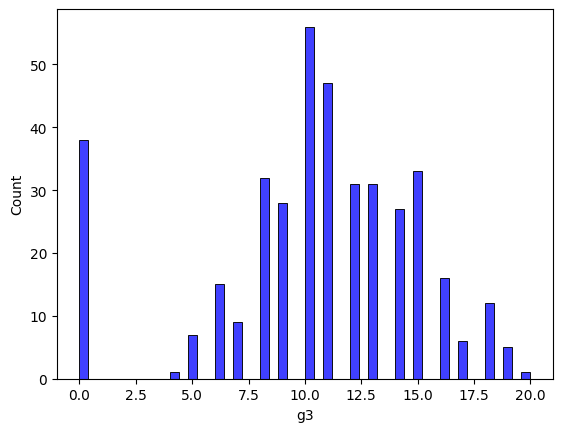

In [126]:
sns.histplot(df.g3, bins=50, color='b')

In [127]:
df.g3.median()

np.float64(11.0)

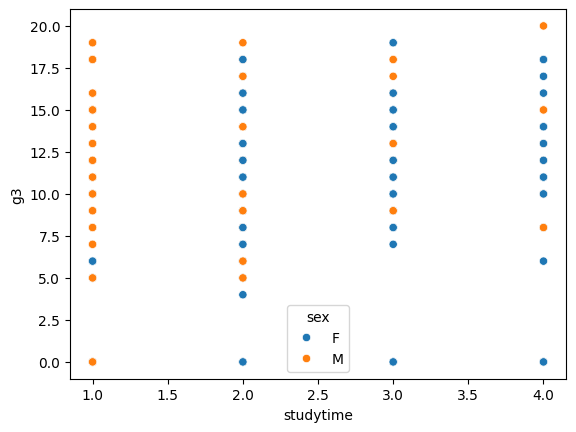

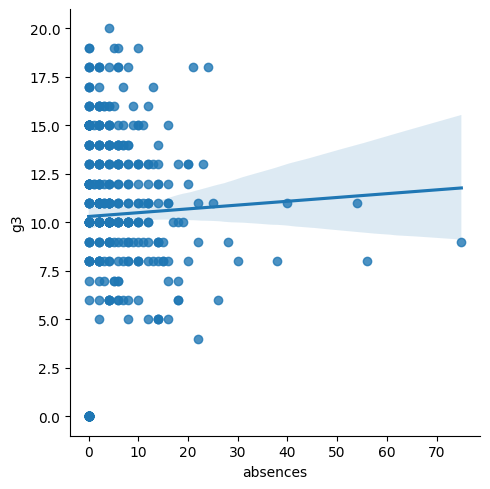

In [128]:
sns.scatterplot(x="studytime", y="g3", data=df, hue="sex")
sns.lmplot(x="absences", y="g3", data=df)

## 3. Validation Framework

In [129]:
df.iloc[:10]

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15


In [130]:
n = len(df)
n

395

In [131]:
from sklearn.model_selection import train_test_split

In [132]:
df_full_train, df_test = train_test_split(df, test_size=0.2, random_state=1)
df_train, df_val = train_test_split(df_full_train, test_size=0.25, random_state=1)

len(df_train), len(df_val), len(df_test)

(237, 79, 79)

In [133]:
n_train = len(df_train)
n_val = len(df_val)
n_test = len(df_test)

n_train, n_val, n_test

(237, 79, 79)

In [134]:
df.iloc[:n_train]

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,GP,M,17,U,GT3,T,4,4,teacher,teacher,...,4,5,5,1,3,2,14,11,9,9
233,GP,M,16,U,GT3,T,4,4,health,other,...,4,2,4,2,4,1,2,14,13,13
234,GP,M,16,U,LE3,T,1,1,other,other,...,3,4,2,1,1,5,18,9,7,6
235,GP,M,16,U,GT3,T,3,2,at_home,other,...,5,3,3,1,3,2,10,11,9,10


In [135]:
idx = np.arange(n)
idx

array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  61,  62,  63,  64,
        65,  66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,
        78,  79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,
        91,  92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103,
       104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116,
       117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129,
       130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142,
       143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155,
       156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168,
       169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 18

In [136]:
df_train = df.iloc[idx[:n_train]]
df_val = df.iloc[idx[n_train:n_train+n_val]]
df_test = df.iloc[idx[n_train + n_val:]]

In [137]:
np.random.shuffle(idx)
idx

array([ 35, 310, 180, 203, 358, 302, 364, 190,  59,  74,   0, 373, 308,
        34, 157, 241, 369, 361, 108,  19, 116, 168, 301, 265, 249,  65,
       198, 253, 100,  56,  99, 338,  98, 224, 341,  67, 115, 112,  75,
        40, 272, 155, 367, 283, 335, 276,  33, 184, 186,  86, 295,  87,
       191, 247,  71,  64, 305, 339, 372, 231, 393,  24, 284, 374, 309,
       340, 392,  76, 334, 162, 319, 200, 142, 389, 197, 379, 240, 229,
       207,   9, 127, 296,  93, 348, 245,  82,  72, 378,  10, 320, 352,
       205, 280, 237, 354, 251, 173, 243, 236, 232,  70, 177, 264, 144,
       192, 214, 138,  37, 126, 290, 365, 381, 383,  81, 293, 371,  69,
        63,  88, 134, 189, 219, 391,  55, 344, 303,  62, 109,  31, 324,
       102,  53,  66, 208, 136, 266, 318, 337, 331, 113, 149, 333, 346,
        14, 282, 170, 261, 271, 182, 172, 217, 141, 325, 212, 327, 220,
       195, 239,  90, 377, 161, 328, 384, 244, 234,  18, 169, 263, 175,
       194, 193, 273, 388, 316, 223,  91, 256, 278,  36, 353, 13

In [138]:
df_train

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,GP,M,17,U,GT3,T,4,4,teacher,teacher,...,4,5,5,1,3,2,14,11,9,9
233,GP,M,16,U,GT3,T,4,4,health,other,...,4,2,4,2,4,1,2,14,13,13
234,GP,M,16,U,LE3,T,1,1,other,other,...,3,4,2,1,1,5,18,9,7,6
235,GP,M,16,U,GT3,T,3,2,at_home,other,...,5,3,3,1,3,2,10,11,9,10


In [139]:
df_train = df_train.reset_index(drop=True)
df_val = df_val.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

In [140]:
df_train

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,famrel,freetime,goout,dalc,walc,health,absences,g1,g2,g3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,GP,M,17,U,GT3,T,4,4,teacher,teacher,...,4,5,5,1,3,2,14,11,9,9
233,GP,M,16,U,GT3,T,4,4,health,other,...,4,2,4,2,4,1,2,14,13,13
234,GP,M,16,U,LE3,T,1,1,other,other,...,3,4,2,1,1,5,18,9,7,6
235,GP,M,16,U,GT3,T,3,2,at_home,other,...,5,3,3,1,3,2,10,11,9,10


In [141]:
df_val.g3.values

array([12, 11,  0, 12, 12,  0, 12,  0, 18, 13,  8,  5, 15,  8, 10,  8,  8,
       12,  8, 13, 11, 14,  0, 18,  8, 12,  9,  0, 17, 10, 11, 10,  0,  9,
       14, 11, 14, 10, 12,  9,  9,  8, 10,  8, 10, 12, 10, 11, 11, 19, 12,
       14, 15, 11, 15, 13, 18, 14, 11,  0,  8, 14, 16, 11, 10, 14, 18, 13,
       12, 18,  8, 12, 10,  0, 13, 11, 11, 13, 11])

In [142]:
y_train = df_train.g3.values
y_val = df_val.g3.values
y_test = df_test.g3.values

In [143]:
df_train.g3[:10]

0     6
1     6
2    10
3    15
4    10
5    15
6    11
7     6
8    19
9    15
Name: g3, dtype: int64

In [144]:
value_log = np.log1p(df_train.g3[:10])
value_log

0    1.945910
1    1.945910
2    2.397895
3    2.772589
4    2.397895
5    2.772589
6    2.484907
7    1.945910
8    2.995732
9    2.772589
Name: g3, dtype: float64

In [277]:
y_train = np.log1p(df_train.g3.values) # 237
y_val = np.log1p(df_val.g3.values) # 79
y_test = np.log1p(df_test.g3.values) # 79

del df_train['g3']
del df_val['g3']
del df_test['g3']

## 4. Linear Regression

In [278]:
len(y_train), len(y_val), len(y_test)

(237, 79, 79)

In [279]:
df_train.iloc[10]

school                GP
sex                    F
age                   15
address                U
famsize              GT3
pstatus                T
medu                   4
fedu                   4
mjob             teacher
fjob              health
reason        reputation
guardian          mother
traveltime             1
studytime              2
failures               0
schoolsup             no
famsup               yes
paid                 yes
activities            no
nursery              yes
higher               yes
internet             yes
romantic              no
famrel                 3
freetime               3
goout                  3
dalc                   1
walc                   2
health                 2
absences               0
g1                    10
g2                     8
Name: 10, dtype: object

In [280]:
xi = [59, 12, 26] # age, studytime, absences
w0 = 0 # bias term
w = [0.01, 0.5, 0.004]

In [281]:
def linear_regression(xi):
    n = len(xi)
    pred = w0

    for j in range(n):
        pred = pred + w[j] * xi[j]
    return pred

In [282]:
predicted_grade = linear_regression(xi)
predicted_grade

6.694

In [283]:
np.expm1(predicted_grade)

np.float64(806.5459843185985)

In [284]:
xi = [59, 12, 26] #
w0 = 7.80
w = [0.01, 0.5, 0.004]

In [285]:
predicted_grade_1 = linear_regression(xi)
predicted_grade_1

np.expm1(predicted_grade_1)

np.float64(1970897.3263506938)

## 5. Linear Regression Vector Form

In [286]:
w0

7.8

In [287]:
def dot(xi, w):
    n = len(xi)
    res = 0.0

    for j in range(n):
        res = res + xi[j] * w[j]
    return res

In [288]:
def linear_regression(xi):
    return w0 + dot(xi, w)

In [289]:
w_new = [w0] + w
w_new

[7.8, 0.01, 0.5, 0.004]

In [290]:
def linear_regression(xi):
    xi = [1] + xi
    return dot(xi, w_new)

In [291]:
linear_regression(xi)

14.494

In [292]:
w, w_new

([0.01, 0.5, 0.004], [7.8, 0.01, 0.5, 0.004])

In [293]:
w0 = 4.8
w = [0.01, 0.5, 0.004]
w_new = [w0] + w

In [294]:
x1  = [1, 16, 10, 2]
x2  = [1, 17, 15, 5]
x10 = [1, 18, 20, 3]

X = [x1, x2, x10]
X = np.array(X)
X

array([[ 1, 16, 10,  2],
       [ 1, 17, 15,  5],
       [ 1, 18, 20,  3]])

In [295]:
w_new, X

([4.8, 0.01, 0.5, 0.004],
 array([[ 1, 16, 10,  2],
        [ 1, 17, 15,  5],
        [ 1, 18, 20,  3]]))

In [296]:
X.shape[0]

3

In [297]:
def linear_regression_vec(X):
    return X.dot(w_new)

In [298]:
linear_regression_vec(X)

array([ 9.968, 12.49 , 14.992])

In [299]:
np.expm1(y_train)

array([ 6.,  6., 10., 15., 10., 15., 11.,  6., 19., 15.,  9., 12., 14.,
       11., 16., 14., 14., 10.,  5., 10., 15., 15., 16., 12.,  8.,  8.,
       11., 15., 11., 11., 12., 17., 16., 12., 15.,  6., 18., 15., 11.,
       13., 11., 12., 18., 11.,  9.,  6., 11., 20., 14.,  7., 13., 13.,
       10., 11., 13., 10., 15., 15.,  9., 16., 11., 11.,  9.,  9., 10.,
       15., 12.,  6.,  8., 16., 15., 10.,  5., 14., 11., 10., 10., 11.,
       10.,  5., 12., 11.,  6., 15., 10.,  8.,  6., 14., 10.,  7.,  8.,
       18.,  6., 10., 14., 10., 15., 10., 14.,  8.,  5., 17., 14.,  6.,
       18., 11.,  8., 18., 13., 16., 19., 10., 13., 19.,  9., 16., 14.,
       13.,  8., 13., 15., 15., 13., 13.,  8., 12., 11.,  9.,  0., 18.,
        0.,  0., 12., 11.,  0.,  0.,  0.,  0., 12., 15.,  0.,  9., 11.,
       13.,  0., 11.,  0., 11.,  0., 10.,  0., 14., 10.,  0., 12.,  8.,
       13., 10., 15., 12.,  0.,  7.,  0., 10.,  7., 12., 10., 16.,  0.,
       14.,  0., 16., 10.,  0.,  9.,  9., 11.,  6.,  9., 11.,  8

## 6. Train Linear Regression Model

In [300]:
X = np.array([
    [16, 10, 2],
    [17, 15, 5],
    [16, 8, 0],
    [18, 20, 3],
    [17, 12, 4],
    [16, 9, 1],
    [18, 18, 2],
    [17, 14, 6]
])
X

array([[16, 10,  2],
       [17, 15,  5],
       [16,  8,  0],
       [18, 20,  3],
       [17, 12,  4],
       [16,  9,  1],
       [18, 18,  2],
       [17, 14,  6]])

In [301]:
X.shape[0]

8

In [302]:
ones = np.ones(X.shape[0])
ones

array([1., 1., 1., 1., 1., 1., 1., 1.])

In [303]:
X

array([[16, 10,  2],
       [17, 15,  5],
       [16,  8,  0],
       [18, 20,  3],
       [17, 12,  4],
       [16,  9,  1],
       [18, 18,  2],
       [17, 14,  6]])

In [304]:
X = np.column_stack([ones, X])
X

array([[ 1., 16., 10.,  2.],
       [ 1., 17., 15.,  5.],
       [ 1., 16.,  8.,  0.],
       [ 1., 18., 20.,  3.],
       [ 1., 17., 12.,  4.],
       [ 1., 16.,  9.,  1.],
       [ 1., 18., 18.,  2.],
       [ 1., 17., 14.,  6.]])

In [305]:
y_train

array([1.94591015, 1.94591015, 2.39789527, 2.77258872, 2.39789527,
       2.77258872, 2.48490665, 1.94591015, 2.99573227, 2.77258872,
       2.30258509, 2.56494936, 2.7080502 , 2.48490665, 2.83321334,
       2.7080502 , 2.7080502 , 2.39789527, 1.79175947, 2.39789527,
       2.77258872, 2.77258872, 2.83321334, 2.56494936, 2.19722458,
       2.19722458, 2.48490665, 2.77258872, 2.48490665, 2.48490665,
       2.56494936, 2.89037176, 2.83321334, 2.56494936, 2.77258872,
       1.94591015, 2.94443898, 2.77258872, 2.48490665, 2.63905733,
       2.48490665, 2.56494936, 2.94443898, 2.48490665, 2.30258509,
       1.94591015, 2.48490665, 3.04452244, 2.7080502 , 2.07944154,
       2.63905733, 2.63905733, 2.39789527, 2.48490665, 2.63905733,
       2.39789527, 2.77258872, 2.77258872, 2.30258509, 2.83321334,
       2.48490665, 2.48490665, 2.30258509, 2.30258509, 2.39789527,
       2.77258872, 2.56494936, 1.94591015, 2.19722458, 2.83321334,
       2.77258872, 2.39789527, 1.79175947, 2.7080502 , 2.48490

In [306]:
y = [1, 5, 25, 30, 10, 15, 20, 20]
y

[1, 5, 25, 30, 10, 15, 20, 20]

In [307]:
XTX = X.T.dot(X)
XTX

array([[   8.,  135.,  106.,   23.],
       [ 135., 2283., 1813.,  393.],
       [ 106., 1813., 1534.,  332.],
       [  23.,  393.,  332.,   95.]])

In [308]:
w_full = XTX.dot(X.T).dot(y)
w_full

array([ 487709., 8285359., 6753863., 1470741.])

In [309]:
w0 = w_full[0]
w = w_full[1:]
w0, w

(np.float64(487709.0), array([8285359., 6753863., 1470741.]))

In [310]:
def train_linear_regression(X, y):
    # Add a column of ones for the intercept
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    
    w_full, residuals, rank, s = np.linalg.lstsq(X, y, rcond=None)
    
    # Return intercept and coefficients
    return w_full[0], w_full[1:]


In [311]:
X, y

(array([[ 1., 16., 10.,  2.],
        [ 1., 17., 15.,  5.],
        [ 1., 16.,  8.,  0.],
        [ 1., 18., 20.,  3.],
        [ 1., 17., 12.,  4.],
        [ 1., 16.,  9.,  1.],
        [ 1., 18., 18.,  2.],
        [ 1., 17., 14.,  6.]]),
 [1, 5, 25, 30, 10, 15, 20, 20])

In [312]:
train_linear_regression(X, y)

(np.float64(-74.29171381868437),
 array([-74.29171382,  10.64478813,  -0.67559412,  -2.2072174 ]))

## 7. RMSE

In [313]:
base = ['age','studytime','absences']

X_train = df_train[base].values
X_train

array([[18,  2,  6],
       [17,  2,  4],
       [15,  2, 10],
       [15,  3,  2],
       [16,  2,  4],
       [16,  2, 10],
       [16,  2,  0],
       [17,  2,  6],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [15,  3,  4],
       [15,  1,  2],
       [15,  2,  2],
       [15,  3,  0],
       [16,  1,  4],
       [16,  3,  6],
       [16,  2,  4],
       [17,  1, 16],
       [16,  1,  4],
       [15,  2,  0],
       [15,  1,  0],
       [16,  2,  2],
       [16,  2,  0],
       [15,  3,  2],
       [16,  1, 14],
       [15,  1,  2],
       [15,  1,  4],
       [16,  2,  4],
       [16,  2, 16],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [16,  1,  0],
       [15,  1,  0],
       [15,  3,  2],
       [16,  3,  7],
       [15,  3,  2],
       [15,  1,  8],
       [16,  2, 25],
       [15,  1,  8],
       [15,  2,  2],
       [15,  1,  0],
       [16,  2, 14],
       [15,  2,  8],
       [16,  2, 12],
       [16,  

In [314]:
y_pred = w0 + X_train.dot(w)
y_pred

array([1.71956343e+08, 1.60729502e+08, 1.52983230e+08, 1.47971165e+08,
       1.52444143e+08, 1.61268589e+08, 1.46561179e+08, 1.63670984e+08,
       1.38275820e+08, 1.38275820e+08, 1.38275820e+08, 1.50912647e+08,
       1.34463439e+08, 1.41217302e+08, 1.45029683e+08, 1.45690280e+08,
       1.62139488e+08, 1.52444143e+08, 1.71624531e+08, 1.45690280e+08,
       1.38275820e+08, 1.31521957e+08, 1.49502661e+08, 1.46561179e+08,
       1.47971165e+08, 1.60397690e+08, 1.34463439e+08, 1.37404921e+08,
       1.52444143e+08, 1.70093035e+08, 1.38275820e+08, 1.38275820e+08,
       1.38275820e+08, 1.38275820e+08, 1.39807316e+08, 1.31521957e+08,
       1.47971165e+08, 1.63610229e+08, 1.47971165e+08, 1.43287885e+08,
       1.83329704e+08, 1.43287885e+08, 1.41217302e+08, 1.31521957e+08,
       1.67151553e+08, 1.50041748e+08, 1.64210071e+08, 1.65951869e+08,
       1.41217302e+08, 1.41217302e+08, 1.49502661e+08, 1.41217302e+08,
       1.40346403e+08, 1.31521957e+08, 1.40346403e+08, 1.58327107e+08,
      

In [315]:
def rmse(y, y_pred):
    se = ((y - y_pred) ** 2).mean()
    return np.sqrt(se)

In [316]:
y_pred

array([1.71956343e+08, 1.60729502e+08, 1.52983230e+08, 1.47971165e+08,
       1.52444143e+08, 1.61268589e+08, 1.46561179e+08, 1.63670984e+08,
       1.38275820e+08, 1.38275820e+08, 1.38275820e+08, 1.50912647e+08,
       1.34463439e+08, 1.41217302e+08, 1.45029683e+08, 1.45690280e+08,
       1.62139488e+08, 1.52444143e+08, 1.71624531e+08, 1.45690280e+08,
       1.38275820e+08, 1.31521957e+08, 1.49502661e+08, 1.46561179e+08,
       1.47971165e+08, 1.60397690e+08, 1.34463439e+08, 1.37404921e+08,
       1.52444143e+08, 1.70093035e+08, 1.38275820e+08, 1.38275820e+08,
       1.38275820e+08, 1.38275820e+08, 1.39807316e+08, 1.31521957e+08,
       1.47971165e+08, 1.63610229e+08, 1.47971165e+08, 1.43287885e+08,
       1.83329704e+08, 1.43287885e+08, 1.41217302e+08, 1.31521957e+08,
       1.67151553e+08, 1.50041748e+08, 1.64210071e+08, 1.65951869e+08,
       1.41217302e+08, 1.41217302e+08, 1.49502661e+08, 1.41217302e+08,
       1.40346403e+08, 1.31521957e+08, 1.40346403e+08, 1.58327107e+08,
      

In [317]:
y_train

array([1.94591015, 1.94591015, 2.39789527, 2.77258872, 2.39789527,
       2.77258872, 2.48490665, 1.94591015, 2.99573227, 2.77258872,
       2.30258509, 2.56494936, 2.7080502 , 2.48490665, 2.83321334,
       2.7080502 , 2.7080502 , 2.39789527, 1.79175947, 2.39789527,
       2.77258872, 2.77258872, 2.83321334, 2.56494936, 2.19722458,
       2.19722458, 2.48490665, 2.77258872, 2.48490665, 2.48490665,
       2.56494936, 2.89037176, 2.83321334, 2.56494936, 2.77258872,
       1.94591015, 2.94443898, 2.77258872, 2.48490665, 2.63905733,
       2.48490665, 2.56494936, 2.94443898, 2.48490665, 2.30258509,
       1.94591015, 2.48490665, 3.04452244, 2.7080502 , 2.07944154,
       2.63905733, 2.63905733, 2.39789527, 2.48490665, 2.63905733,
       2.39789527, 2.77258872, 2.77258872, 2.30258509, 2.83321334,
       2.48490665, 2.48490665, 2.30258509, 2.30258509, 2.39789527,
       2.77258872, 2.56494936, 1.94591015, 2.19722458, 2.83321334,
       2.77258872, 2.39789527, 1.79175947, 2.7080502 , 2.48490

<Axes: ylabel='Count'>

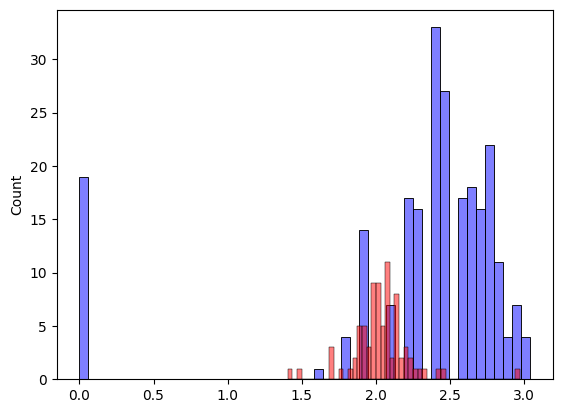

In [337]:
sns.histplot(y_train, color='blue', alpha=0.5, bins=50)
sns.histplot(y_pred, color='red', alpha=0.5, bins=50)

In [321]:
root_result = rmse(y_train, y_pred)
round(root_result, 2)

np.float64(154675659.04)

In [322]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [323]:
df_train

,school,sex,age,address,famsize,pstatus,medu,fedu,mjob,fjob,...,romantic,famrel,freetime,goout,dalc,walc,health,absences,g1,g2
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,no,4,3,4,1,1,3,6,5,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,no,5,3,3,1,1,3,4,5,5
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,no,4,3,2,2,3,3,10,7,8
3,GP,F,15,U,GT3,T,4,2,health,services,...,yes,3,2,2,1,1,5,2,15,14
4,GP,F,16,U,GT3,T,3,3,other,other,...,no,4,3,2,1,2,5,4,6,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
232,GP,M,17,U,GT3,T,4,4,teacher,teacher,...,yes,4,5,5,1,3,2,14,11,9
233,GP,M,16,U,GT3,T,4,4,health,other,...,no,4,2,4,2,4,1,2,14,13
234,GP,M,16,U,LE3,T,1,1,other,other,...,no,3,4,2,1,1,5,18,9,7
235,GP,M,16,U,GT3,T,3,2,at_home,other,...,yes,5,3,3,1,3,2,10,11,9


In [324]:
X_train = prepare_X(df_train)
X_train

array([[18,  2,  6],
       [17,  2,  4],
       [15,  2, 10],
       [15,  3,  2],
       [16,  2,  4],
       [16,  2, 10],
       [16,  2,  0],
       [17,  2,  6],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [15,  3,  4],
       [15,  1,  2],
       [15,  2,  2],
       [15,  3,  0],
       [16,  1,  4],
       [16,  3,  6],
       [16,  2,  4],
       [17,  1, 16],
       [16,  1,  4],
       [15,  2,  0],
       [15,  1,  0],
       [16,  2,  2],
       [16,  2,  0],
       [15,  3,  2],
       [16,  1, 14],
       [15,  1,  2],
       [15,  1,  4],
       [16,  2,  4],
       [16,  2, 16],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [15,  2,  0],
       [16,  1,  0],
       [15,  1,  0],
       [15,  3,  2],
       [16,  3,  7],
       [15,  3,  2],
       [15,  1,  8],
       [16,  2, 25],
       [15,  1,  8],
       [15,  2,  2],
       [15,  1,  0],
       [16,  2, 14],
       [15,  2,  8],
       [16,  2, 12],
       [16,  

In [333]:
w0, w = train_linear_regression(X_train, y_train)
w0, w

(np.float64(4.738429070172057), array([-0.16423067,  0.04585239,  0.0146646 ]))

In [334]:
rmse(y_train, y_pred)

np.float64(154675659.03685254)

In [335]:
X_val = prepare_X(df_val)
y_pred = w0 + X_val.dot(w)
X_val, y_pred

(array([[16,  1, 20],
        [17,  2,  2],
        [18,  2,  0],
        [17,  2, 14],
        [17,  2,  2],
        [16,  1,  0],
        [16,  1,  0],
        [18,  3,  0],
        [16,  1,  6],
        [17,  1,  4],
        [22,  1, 16],
        [18,  2,  8],
        [16,  1,  0],
        [18,  1,  0],
        [16,  2,  6],
        [18,  1,  4],
        [16,  1,  0],
        [17,  1,  0],
        [17,  1,  2],
        [17,  4,  6],
        [19,  2, 12],
        [18,  2,  8],
        [17,  4,  0],
        [18,  2, 21],
        [18,  2,  2],
        [18,  3,  1],
        [17,  3,  4],
        [18,  3,  0],
        [18,  2, 13],
        [17,  2,  2],
        [18,  2,  8],
        [18,  2, 10],
        [18,  2,  0],
        [19,  2, 15],
        [18,  4,  4],
        [18,  2,  2],
        [17,  2,  2],
        [17,  2,  2],
        [17,  2,  6],
        [18,  2, 75],
        [18,  1, 22],
        [18,  2, 15],
        [18,  1,  8],
        [17,  1, 30],
        [17,  1, 19],
        [1

In [336]:
rmse(y_val, y_pred)

np.float64(0.8101708154941125)

## 8. Feature Engineering

## 9. One-Hot Encoding

## 10. Regularization

## 11. Model Tuning

## 12. Final Model